# XGBoost Classifier

## Project

Pima Indians Diabetes Dataset Classification Models

---

## Objective

To implement the Extreme Gradient Boosting (XGBoost) classifier and evaluate its performance on the Pima Indians Diabetes Dataset.

The objective is to compare XGBoost with previous machine learning and ensemble learning algorithms to determine its effectiveness in predicting diabetes.

---

## About XGBoost

Extreme Gradient Boosting (XGBoost) is an optimized implementation of the traditional Gradient Boosting algorithm.

Like Gradient Boosting, XGBoost builds decision trees sequentially, where each new tree learns from the residual errors made by previous trees.

However, XGBoost introduces several improvements, including regularisation, faster training, better handling of missing values, and optimized tree construction, making it one of the most widely used algorithms for structured (tabular) machine learning problems.

---

## Why XGBoost?

XGBoost is popular because it:

- Learns from residual errors.
- Reduces overfitting through regularisation.
- Trains faster than traditional Gradient Boosting.
- Produces highly accurate predictive models.
- Is widely used in industry and machine learning competitions.

---

## Workflow

1. Import the XGBoost Classifier.
2. Create the model.
3. Train the model.
4. Generate predictions.
5. Evaluate performance using:
   - Accuracy
   - Classification Report
   - Confusion Matrix
   - ROC-AUC Score
6. Compare the results with previous ensemble learning models.

In [14]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

# LOAD DATA

In [15]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# FEATURES AND TARGET

In [16]:
# Featues
X = df.drop("Outcome", axis=1)
# Target
y = df["Outcome"]

# TRAIN TEST SPLIT

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# TRAINING THE XGBoost MODEL

In [18]:
xgb = XGBClassifier(
    n_estimators=50,
    learning_rate=0.1, #small gradual learning 
    max_depth=3, # moderately dimple treess
    random_state=42,
    eval_metric="logloss" #evaluates how confident the model is about its prediction
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# MAKING PREDICTION

In [19]:
# Y_pred gives the final prediction of each patient
y_pred = xgb.predict(X_test)
# Y_prob gives the probability of a patient being in class 1(Diabetic)
y_prob = xgb.predict_proba(X_test)[:, 1]


#  EVALUATING THE MODELS PERFORMANCE

In [9]:
# Accuracy
xgb_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {xgb_accuracy:.2f}")

Accuracy: 0.76


In [10]:
# Classification Report
cr = classification_report(y_test, y_pred)
print(f"Classification Report: {cr}")

Classification Report:               precision    recall  f1-score   support

           0       0.82      0.81      0.81        99
           1       0.66      0.67      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



Confusion Matrix: [[80 19]
 [18 37]]


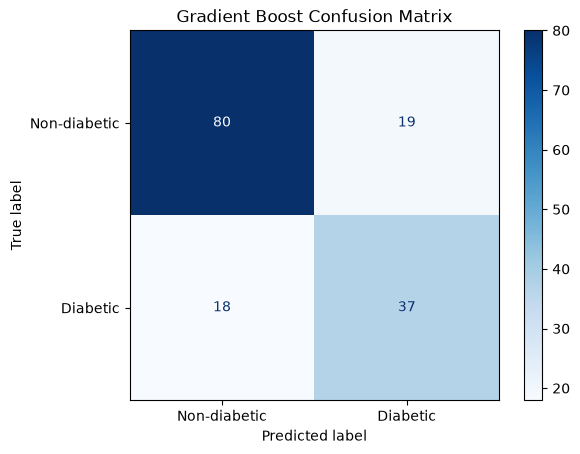

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: {cm}")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-diabetic", "Diabetic"]
)
disp.plot(cmap="Blues")
plt.title("Gradient Boost Confusion Matrix")
plt.show()

ROC-AUC Score: 0.82


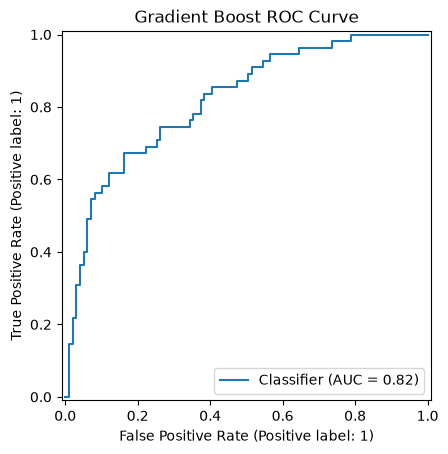

In [22]:
# ROC_AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(roc_auc, 2))
# ROC_AUC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Gradient Boost ROC Curve")
plt.show()

# CONSLUSION


The XGBoost Classifier achieved an accuracy of **76%** and a **ROC-AUC score of 0.82** on the test dataset.

Although XGBoost is an optimized implementation of Gradient Boosting with additional features such as regularisation and improved computational efficiency, it did not outperform the traditional Gradient Boosting model on this dataset using the selected hyperparameters.

Gradient Boosting achieved a slightly higher accuracy of **77%** and the same ROC-AUC score of **0.82**, while also achieving better recall for diabetic patients.

This result demonstrates that a more advanced or optimized algorithm does not necessarily produce better results on every dataset. Model performance depends on the characteristics of the data, the selected hyperparameters, and the evaluation metric being considered.

Overall, XGBoost performed competitively and demonstrated strong classification ability, making it a valuable model to include in the final comparison.